In [1]:
print("all ok")

all ok


In [2]:
import sys, os

# Get project root — one level up from 'research_and_analyst'
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

print("Project root added to path:", project_root)

Project root added to path: d:\ARTIFICIAL INTELLIGENCE\Multi-Agent System for Research Analysis and Generation Automation\automated-research-synthesis


In [3]:
from research_and_analyst.utils.model_loader import ModelLoader

In [4]:
model_loader = ModelLoader()

{"timestamp": "2026-08-19T06:45:19.904285Z", "level": "info", "event": "Initializing ApiKeyManager"}
{"timestamp": "2026-08-19T06:45:19.905541Z", "level": "info", "event": "ANTHROPIC_API_KEY loaded successfully from environment"}
{"timestamp": "2026-08-19T06:45:19.906451Z", "level": "info", "event": "OPENAI_API_KEY loaded successfully from environment"}
{"timestamp": "2026-08-19T06:45:19.907292Z", "level": "info", "event": "GOOGLE_API_KEY loaded successfully from environment"}
{"timestamp": "2026-08-19T06:45:19.908168Z", "level": "info", "event": "GROQ_API_KEY loaded successfully from environment"}
{"path": "D:\\ARTIFICIAL INTELLIGENCE\\Multi-Agent System for Research Analysis and Generation Automation\\automated-research-synthesis\\research_and_analyst\\config\\configuration.yaml", "keys": ["astra_db", "embedding_model", "retriever", "llm"], "timestamp": "2026-08-19T06:45:19.912996Z", "level": "info", "event": "Configuration loaded successfully"}
{"config_keys": ["astra_db", "embeddin

In [5]:
llm=model_loader.load_llm()

{"provider": "anthropic", "model": "claude-sonnet-4-5-20250929", "timestamp": "2026-08-19T06:45:19.923809Z", "level": "info", "event": "Loading LLM"}
{"provider": "anthropic", "model": "claude-sonnet-4-5-20250929", "timestamp": "2026-08-19T06:45:19.925494Z", "level": "info", "event": "LLM loaded successfully"}


In [6]:
llm.invoke("hi").content

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


'Hello! How can I help you today?'

In [7]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

In [8]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage,HumanMessage , SystemMessage
from langgraph.checkpoint.memory import MemorySaver

In [9]:
class Analyst(BaseModel):
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, concerns, and motives.")
    
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

In [10]:
Analyst(
    name="Nikhil Srivastava",
    role="Agentic AI eng",
    affiliation="AI Research LAB",
    description="I am genai developer as well as mentor"
    )

Analyst(name='Nikhil Srivastava', role='Agentic AI eng', affiliation='AI Research LAB', description='I am genai developer as well as mentor')

In [11]:
analyst = Analyst(
    name="Nikhil Srivastava",
    role="Agentic AI eng",
    affiliation="AI Research LAB",
    description="I am genai developer as well as mentor"
    )

In [12]:
analyst.name

'Nikhil Srivastava'

In [13]:
analyst.role

'Agentic AI eng'

In [14]:
analyst.affiliation

'AI Research LAB'

In [15]:
print(analyst.persona)

Name: Nikhil Srivastava
Role: Agentic AI eng
Affiliation: AI Research LAB
Description: I am genai developer as well as mentor



In [16]:
class Perspectives(BaseModel):
       analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [17]:
class GenerateAnalystsState(TypedDict):
    topic: str #research topic
    max_analysts: int # number of analyst
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

In [18]:
GenerateAnalystsState(
    topic = "finance",
    max_analysts= 5,
    human_analyst_feedback= "give the real info",  
)

{'topic': 'finance',
 'max_analysts': 5,
 'human_analyst_feedback': 'give the real info'}

In [19]:
Analyst(
        name="Dr. Neha Patel",
        role="Medical Data Scientist",
        affiliation="Stanford Medicine",
        description="Focuses on predictive models for patient outcomes."
    ),

(Analyst(name='Dr. Neha Patel', role='Medical Data Scientist', affiliation='Stanford Medicine', description='Focuses on predictive models for patient outcomes.'),)

In [20]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [21]:
print([analyst_instructions.format(
        topic="education",
        max_analysts=4,
        human_analyst_feedback="please exaplain only on AI"
        
        )] + ["Generate the set of analysts."])

['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']


In [22]:
def create_analyst(state:GenerateAnalystsState):
    """
    it is creating my analyst
    
    """
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback","")
    
    structured_llm = llm.with_structured_output(Perspectives)
    
    system_messages = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
        
        )
    analysts = structured_llm.invoke([SystemMessage(content=system_messages)]+ [HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

In [23]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 2,
    'human_analyst_feedback': 'give the real info'}
    )

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Sarah Chen', role='Public Health Equity Researcher', affiliation='Johns Hopkins Bloomberg School of Public Health', description='Dr. Chen specializes in health disparities and social determinants of health. Her primary focus is on understanding how socioeconomic factors, race, geography, and access to care create inequities in health outcomes. She is deeply concerned with vulnerable populations including low-income communities, racial minorities, and rural residents who face systemic barriers to healthcare. Her research examines policy interventions that can reduce these gaps, including Medicaid expansion, community health worker programs, and culturally competent care models. She is motivated by a commitment to health justice and believes that healthcare is a fundamental human right that should be accessible to all regardless of background or ability to pay.'),
  Analyst(name='Dr. Michael Torres', role='Digital Health Innovation Specialist', affiliation

In [24]:
def human_feedback(state):
    """ No-op node that should be interrupted on """
    pass

In [25]:
def should_continue(state):
    feedback = (state.get("human_analyst_feedback") or "").strip().lower()
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END

In [26]:
from IPython.display import Image, display

In [27]:
builder = StateGraph(GenerateAnalystsState)

In [28]:
builder.add_node("create_analyst",create_analyst)
builder.add_node("human_feedback", human_feedback)

In [29]:
builder.add_edge(START,"create_analyst")
builder.add_edge("create_analyst", "human_feedback")
builder.add_conditional_edges("human_feedback",
                        should_continue,
                        ["create_analyst",
                        END])

In [30]:
memory = MemorySaver()

In [31]:
graph = builder.compile(interrupt_before= ["human_feedback"],checkpointer= memory)

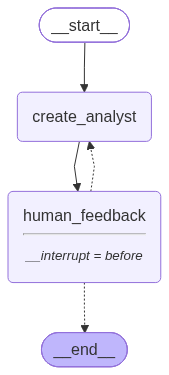

In [32]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [33]:
topic = "the benefits of adopting Langgraph as an agent framework"

In [34]:
max_analysts = 4

In [35]:
thread =  {"configurable":{"thread_id":1}}

In [36]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Name: Dr. Sarah Chen
Affiliation: Enterprise AI Solutions Lab
Role: AI Architecture Specialist
Description: Dr. Chen focuses on the technical architecture and design patterns enabled by Langgraph. She is particularly interested in how Langgraph's graph-based approach to agent orchestration compares to traditional sequential frameworks, examining state management, control flow flexibility, and the ability to build complex multi-agent systems. Her primary concern is understanding how Langgraph's architecture enables more maintainable and scalable agent applications, and she evaluates the framework's technical merits for production deployments.
--------------------------------------------------
Name: Marcus Rodriguez
Affiliation: DevTools Innovation Institute
Role: Developer Experience Researcher
Description: Marcus specializes in developer productivity and the practical aspects of adopting new frameworks. He examines Langgraph from the perspective of ease of use, learning curve, debuggin